In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

cols = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
        "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]
df = pd.read_csv("../data/processed.cleveland.data",
                 header=None, names=cols, na_values="?")
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])
X = df.drop(columns=["target"]); y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scale_cols  = ["age", "trestbps", "chol", "thalach", "oldpeak"]
onehot_cols = ["cp", "restecg", "thal"]
pass_cols   = ["sex", "fbs", "exang", "slope", "ca"]
preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), scale_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(drop="first",
                                           handle_unknown="ignore"))]), onehot_cols),
    ("pass", SimpleImputer(strategy="most_frequent"), pass_cols),
])

# 最终模型：用第 5 周定选的模型和调好的参数（下面以逻辑回归为例，C 换成你的最佳值）
final_model = Pipeline([("prep", preprocess),
                        ("clf", LogisticRegression(max_iter=1000, C=1, random_state=42))])
final_model.fit(X_train, y_train)
proba = final_model.predict_proba(X_test)[:, 1]

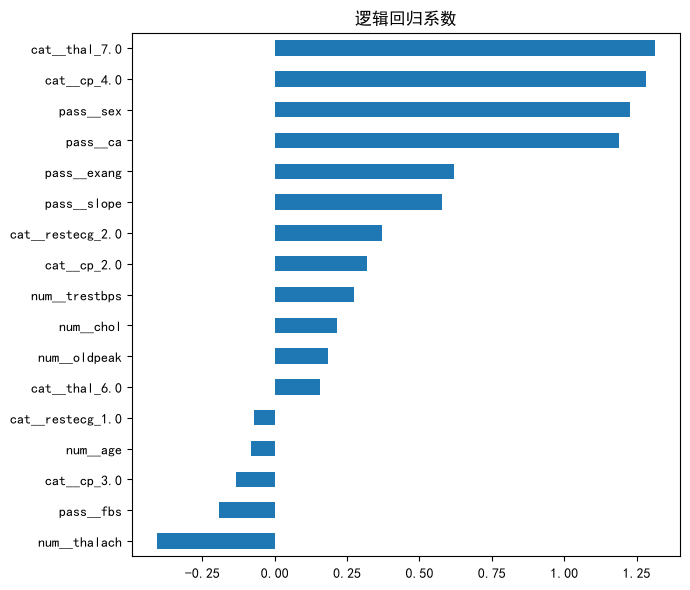

In [15]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

# ① 逻辑回归系数（方向 + 相对强度，前提是已标准化）
feat_names = final_model.named_steps["prep"].get_feature_names_out()
coef = final_model.named_steps["clf"].coef_[0]
s = pd.Series(coef, index=feat_names).sort_values()
s.plot(kind="barh", figsize=(7, 6), title="逻辑回归系数")
plt.tight_layout(); plt.savefig("../figures/lr_coef.png", dpi=150); plt.show()

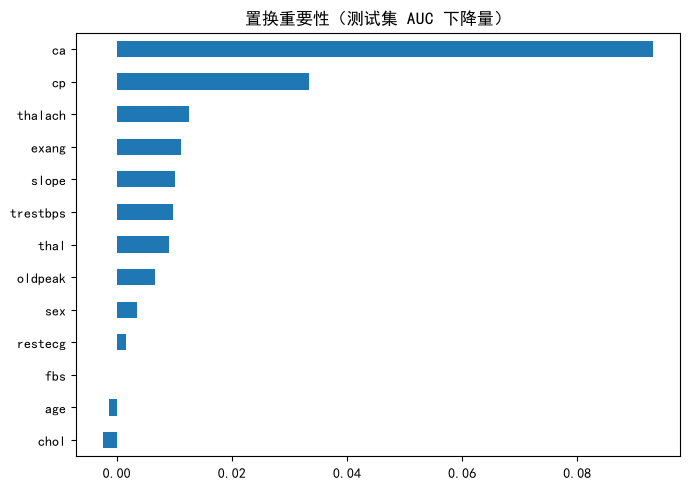

In [16]:
# ② 置换重要性（测试集上缺了它成绩掉多少，适用于任何模型）
r = permutation_importance(final_model, X_test, y_test,
                           n_repeats=30, random_state=42, scoring="roc_auc")
s2 = pd.Series(r.importances_mean, index=X_test.columns).sort_values()
s2.plot(kind="barh", figsize=(7, 5), title="置换重要性（测试集 AUC 下降量）")
plt.tight_layout(); plt.savefig("../figures/permutation.png", dpi=150); plt.show()

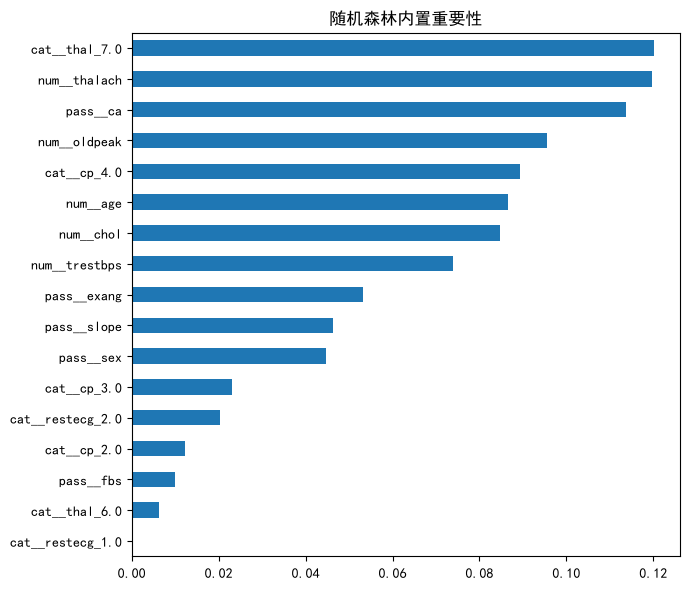

In [17]:
# ③ 随机森林内置重要性（另训一棵森林作对照）
pipe_rf = Pipeline([("prep", preprocess),
                    ("clf", RandomForestClassifier(n_estimators=200, random_state=42))])
pipe_rf.fit(X_train, y_train)
s3 = pd.Series(pipe_rf.named_steps["clf"].feature_importances_,
               index=feat_names).sort_values()
s3.plot(kind="barh", figsize=(7, 6), title="随机森林内置重要性")
plt.tight_layout(); plt.savefig("../figures/rf_importance.png", dpi=150); plt.show()

In [18]:
import shap

Xtr = final_model.named_steps["prep"].transform(X_train)
Xte = final_model.named_steps["prep"].transform(X_test)
if hasattr(Xtr, "toarray"):          # 若输出是稀疏矩阵则转为普通数组
    Xtr = Xtr.toarray(); Xte = Xte.toarray()
model = final_model.named_steps["clf"]

explainer = shap.Explainer(model, Xtr, feature_names=feat_names)
sv = explainer(Xte)

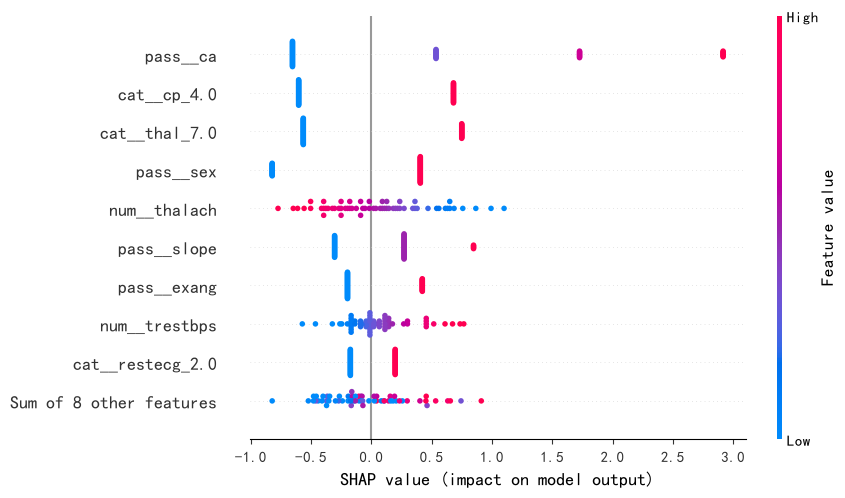

In [19]:
shap.plots.beeswarm(sv)   # 全局：各特征如何影响输出

C:\Users\86135\.conda\envs\heart\Lib\site-packages\shap\plots\_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
C:\Users\86135\.conda\envs\heart\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


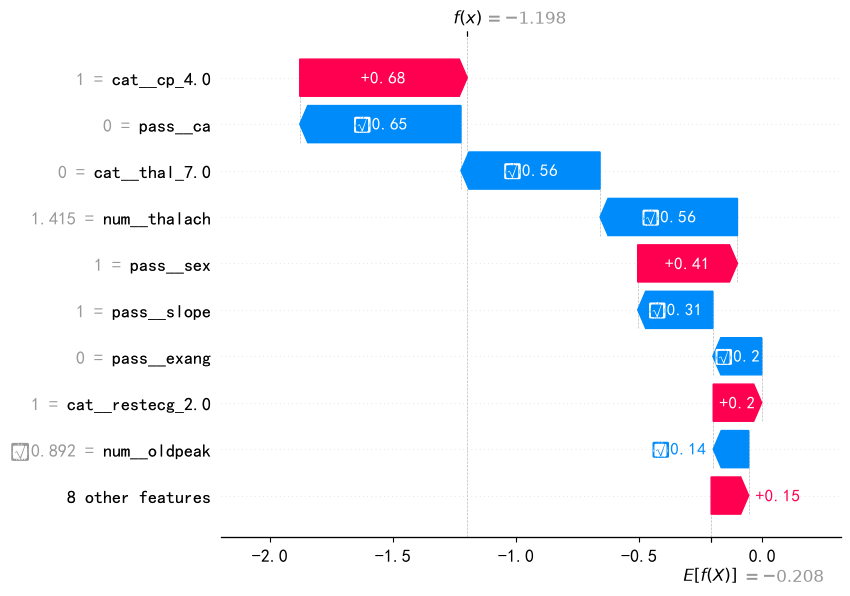

In [20]:
shap.plots.waterfall(sv[0])   # 局部：第一个测试病人的预测如何形成

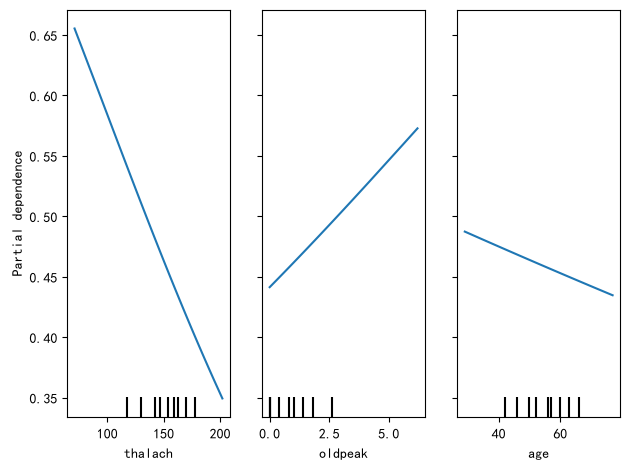

In [21]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    final_model, X_train, features=["thalach", "oldpeak", "age"])
plt.tight_layout(); plt.savefig("../figures/pdp.png", dpi=150); plt.show()

In [23]:
df_hu = pd.read_csv("../data_raw/processed.hungarian.data",
                    header=None, names=cols, na_values="?")
df_hu = df_hu.dropna(subset=["num"])               # 只要求有标签
X_hu = df_hu.drop(columns=["num"])
y_hu = (df_hu["num"] > 0).astype(int)

print(f"匈牙利子库：共 {len(df_hu)} 条，标签分布：{dict(y_hu.value_counts())}")
print("各列缺失数量：")
print(X_hu.isnull().sum())

auc_hu = roc_auc_score(y_hu, final_model.predict_proba(X_hu)[:, 1])
print("匈牙利子库外部验证 AUC:", round(auc_hu, 3))

匈牙利子库：共 294 条，标签分布：{0: np.int64(188), 1: np.int64(106)}
各列缺失数量：
age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
dtype: int64
匈牙利子库外部验证 AUC: 0.886


In [24]:
import joblib
import os
os.makedirs("../app", exist_ok=True)
joblib.dump(final_model, "../app/heart_model.joblib")
print("模型已保存")

模型已保存
